In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from pydantic import BaseModel
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing import Annotated

In [ ]:
class ChatState(BaseModel):
    messages:Annotated[list,add_messages]##add_message append coming message into messages as a list

In [6]:
llm=ChatGoogleGenerativeAI(model="gemini-3.6-flash")

In [7]:
def chatBotNode(state:ChatState) -> ChatState:
    res=llm.invoke(state.messages)
    state.messages=[res]
    return state

In [ ]:
memory=InMemorySaver()##needs to pass the config with messages

In [8]:
grapgh=StateGraph(ChatState)
grapgh.add_node("chatBotNode",chatBotNode)

In [10]:
grapgh.add_edge(START,"chatBotNode")
grapgh.add_edge("chatBotNode",END)

grapgh=grapgh.compile(checkpointer=memory)

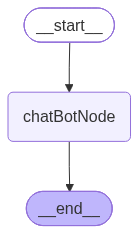

In [12]:
from IPython.display import Image
Image(grapgh.get_graph().draw_mermaid_png())

In [14]:
config={"configurable":{"thread_id":"My-bot-1"}}
res=grapgh.invoke({"messages":[{"role":"user","content":"Hello Hows You ? I am Nithin Kumar M"}]},config)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [17]:
res["messages"][-1].text

"Hello Nithin Kumar! I'm doing great, thank you for asking. It's a pleasure to meet you! \n\nHow are you doing today, and how can I help you out?"